# 💳 Explainable Credit Default Prediction
Using XGBoost + SHAP

## 🎯 Objective
Predict whether a customer will default on a loan and explain the reasons using Explainable AI.

In [1]:
!pip install pandas numpy matplotlib seaborn scikit-learn xgboost shap imbalanced-learn


[notice] A new release of pip is available: 24.0 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


## 1. Import Libraries

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import shap
import pickle

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from xgboost import XGBClassifier

from sklearn.metrics import accuracy_score, roc_auc_score, classification_report, confusion_matrix, roc_curve
from imblearn.over_sampling import SMOTE


## 2. Load Dataset

In [3]:
df = pd.read_csv(r"C:\ML_Projects\Credit_Default_Project\datasets\cs-training.csv")
df.head()

,Unnamed: 0,SeriousDlqin2yrs,RevolvingUtilizationOfUnsecuredLines,age,NumberOfTime30-59DaysPastDueNotWorse,DebtRatio,MonthlyIncome,NumberOfOpenCreditLinesAndLoans,NumberOfTimes90DaysLate,NumberRealEstateLoansOrLines,NumberOfTime60-89DaysPastDueNotWorse,NumberOfDependents
0,1,1,0.766127,45,2,0.802982,9120.0,13,0,6,0,2.0
1,2,0,0.957151,40,0,0.121876,2600.0,4,0,0,0,1.0
2,3,0,0.658180,38,1,0.085113,3042.0,2,1,0,0,0.0
3,4,0,0.233810,30,0,0.036050,3300.0,5,0,0,0,0.0
4,5,0,0.907239,49,1,0.024926,63588.0,7,0,1,0,0.0


## 3. Data Understanding

In [4]:
print("Shape:", df.shape)
df.info()
df.describe()

Shape: (150000, 12)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150000 entries, 0 to 149999
Data columns (total 12 columns):
 #   Column                                Non-Null Count   Dtype  
---  ------                                --------------   -----  
 0   Unnamed: 0                            150000 non-null  int64  
 1   SeriousDlqin2yrs                      150000 non-null  int64  
 2   RevolvingUtilizationOfUnsecuredLines  150000 non-null  float64
 3   age                                   150000 non-null  int64  
 4   NumberOfTime30-59DaysPastDueNotWorse  150000 non-null  int64  
 5   DebtRatio                             150000 non-null  float64
 6   MonthlyIncome                         120269 non-null  float64
 7   NumberOfOpenCreditLinesAndLoans       150000 non-null  int64  
 8   NumberOfTimes90DaysLate               150000 non-null  int64  
 9   NumberRealEstateLoansOrLines          150000 non-null  int64  
 10  NumberOfTime60-89DaysPastDueNotWorse  150000 non

,Unnamed: 0,SeriousDlqin2yrs,RevolvingUtilizationOfUnsecuredLines,age,NumberOfTime30-59DaysPastDueNotWorse,DebtRatio,MonthlyIncome,NumberOfOpenCreditLinesAndLoans,NumberOfTimes90DaysLate,NumberRealEstateLoansOrLines,NumberOfTime60-89DaysPastDueNotWorse,NumberOfDependents
count,150000.000000,150000.000000,150000.000000,150000.000000,150000.000000,150000.000000,1.202690e+05,150000.000000,150000.000000,150000.000000,150000.000000,146076.000000
mean,75000.500000,0.066840,6.048438,52.295207,0.421033,353.005076,6.670221e+03,8.452760,0.265973,1.018240,0.240387,0.757222
std,43301.414527,0.249746,249.755371,14.771866,4.192781,2037.818523,1.438467e+04,5.145951,4.169304,1.129771,4.155179,1.115086
min,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000
25%,37500.750000,0.000000,0.029867,41.000000,0.000000,0.175074,3.400000e+03,5.000000,0.000000,0.000000,0.000000,0.000000
50%,75000.500000,0.000000,0.154181,52.000000,0.000000,0.366508,5.400000e+03,8.000000,0.000000,1.000000,0.000000,0.000000
75%,112500.250000,0.000000,0.559046,63.000000,0.000000,0.868254,8.249000e+03,11.000000,0.000000,2.000000,0.000000,1.000000
max,150000.000000,1.000000,50708.000000,109.000000,98.000000,329664.000000,3.008750e+06,58.000000,98.000000,54.000000,98.000000,20.000000


## 4. Remove Unnecessary Column

In [5]:
df.drop("Unnamed: 0", axis=1, inplace=True)

## 5. Target Column

In [6]:
df["SeriousDlqin2yrs"].value_counts()

SeriousDlqin2yrs
0    139974
1     10026
Name: count, dtype: int64

## 6. Data Cleaning

In [7]:
df.drop_duplicates(inplace=True)
df.replace([np.inf, -np.inf], np.nan, inplace=True)
df.fillna(df.median(), inplace=True)

## 7. Exploratory Data Analysis

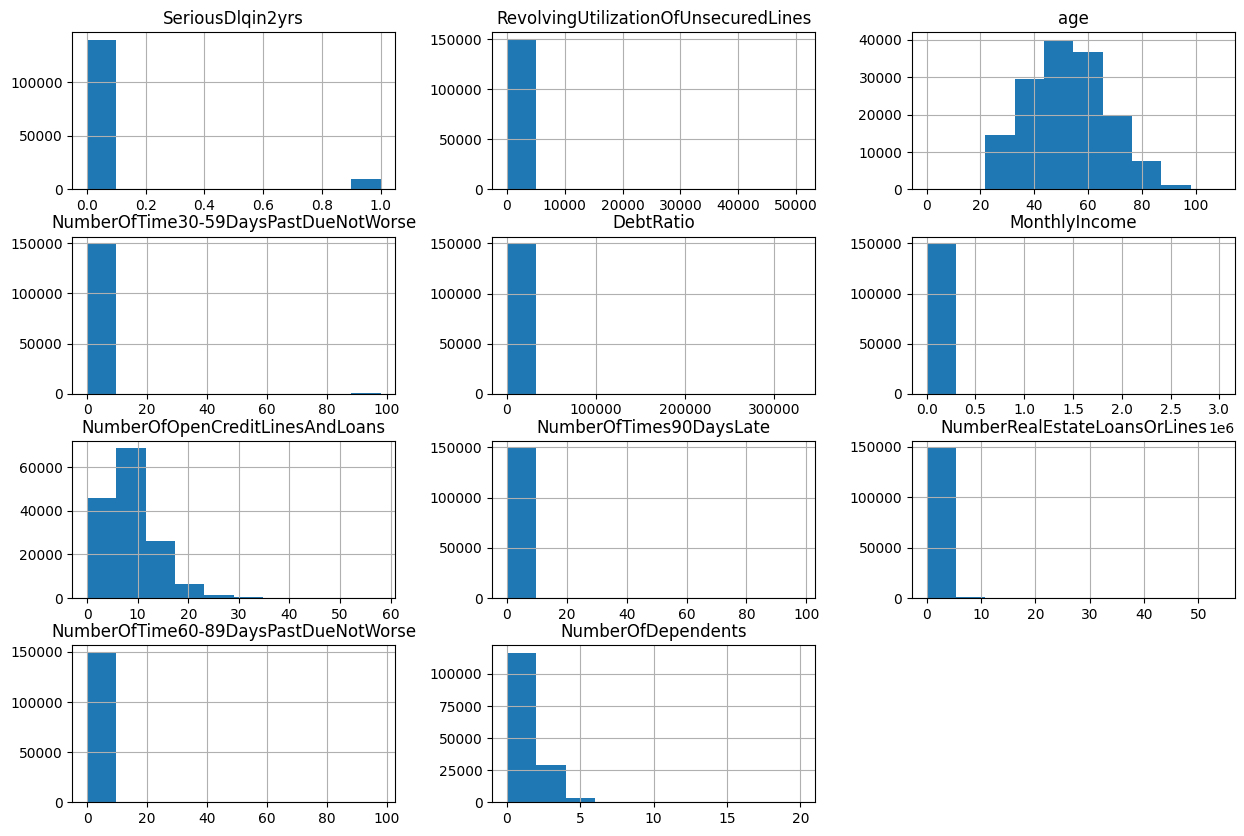

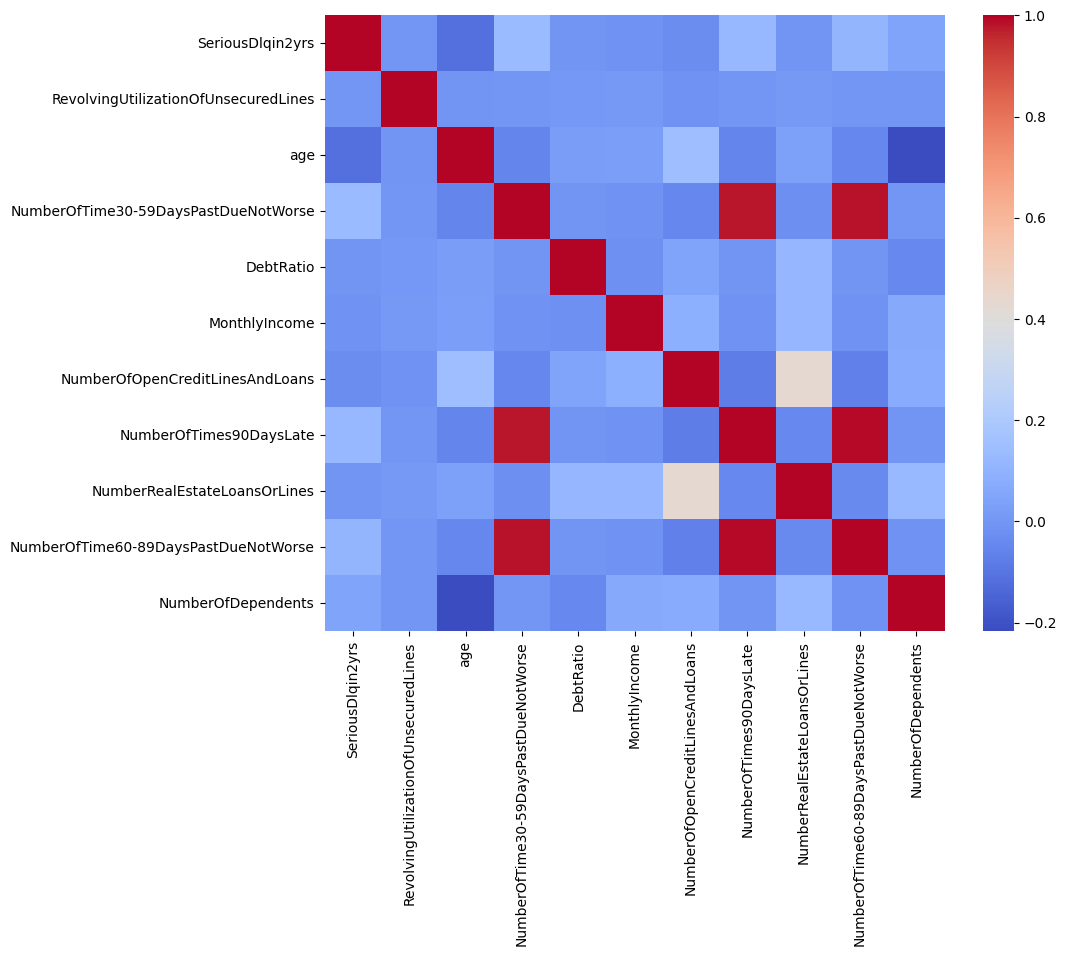

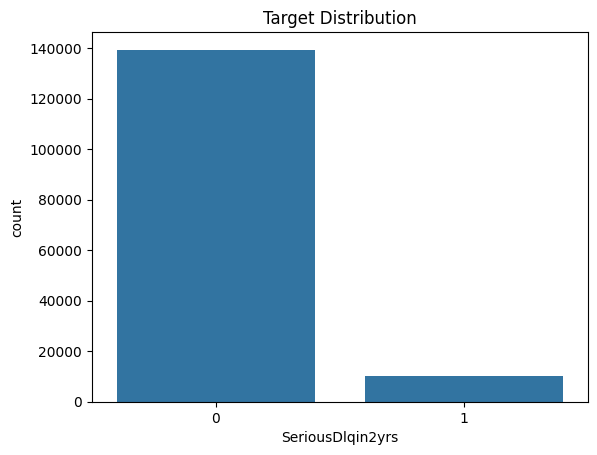

In [8]:
df.hist(figsize=(15,10))
plt.show()

plt.figure(figsize=(10,8))
sns.heatmap(df.corr(), cmap="coolwarm")
plt.show()

sns.countplot(x="SeriousDlqin2yrs", data=df)
plt.title("Target Distribution")
plt.show()

## 8. Feature Engineering

In [9]:
df["income_per_person"] = df["MonthlyIncome"] / (df["NumberOfDependents"] + 1)
df["debt_per_income"] = df["DebtRatio"] / (df["MonthlyIncome"] + 1)
df["late_payment_score"] = df["NumberOfTimes90DaysLate"] + df["NumberOfTime30-59DaysPastDueNotWorse"]

## 9. Train-Test Split

In [20]:
X = df[[
    "DebtRatio",
    "MonthlyIncome",
    "NumberOfTimes90DaysLate",
    "RevolvingUtilizationOfUnsecuredLines"
]]

y = df["SeriousDlqin2yrs"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

## 10. Handle Imbalance (SMOTE)

In [21]:
sm = SMOTE(random_state=42)
X_train, y_train = sm.fit_resample(X_train, y_train)

## 11. Train Models

In [22]:
lr = LogisticRegression(max_iter=3000, solver='liblinear')
lr.fit(X_train, y_train)

dt = DecisionTreeClassifier()
dt.fit(X_train, y_train)

xgb = XGBClassifier(eval_metric='logloss')
xgb.fit(X_train, y_train)

,objective,'binary:logistic'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,None
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,'logloss'


## 12. Predictions

In [23]:
lr_pred = lr.predict(X_test)
lr_prob = lr.predict_proba(X_test)[:,1]

dt_pred = dt.predict(X_test)
dt_prob = dt.predict_proba(X_test)[:,1]

xgb_pred = xgb.predict(X_test)
xgb_prob = xgb.predict_proba(X_test)[:,1]

## 13. Evaluation Metrics

In [24]:
def evaluate(name, y_test, pred, prob):
    print(f"\n{name}")
    print("Accuracy:", accuracy_score(y_test, pred))
    print("AUC:", roc_auc_score(y_test, prob))
    print(classification_report(y_test, pred))

evaluate("Logistic Regression", y_test, lr_pred, lr_prob)
evaluate("Decision Tree", y_test, dt_pred, dt_prob)
evaluate("XGBoost", y_test, xgb_pred, xgb_prob)


Logistic Regression
Accuracy: 0.9195086850296195
AUC: 0.6964960226216435
              precision    recall  f1-score   support

           0       0.95      0.96      0.96     27849
           1       0.40      0.35      0.37      2030

    accuracy                           0.92     29879
   macro avg       0.67      0.65      0.66     29879
weighted avg       0.92      0.92      0.92     29879


Decision Tree
Accuracy: 0.7397837946383747
AUC: 0.6324161775316464
              precision    recall  f1-score   support

           0       0.95      0.76      0.84     27849
           1       0.13      0.51      0.21      2030

    accuracy                           0.74     29879
   macro avg       0.54      0.63      0.53     29879
weighted avg       0.90      0.74      0.80     29879


XGBoost
Accuracy: 0.7517319856755581
AUC: 0.7832023401358523
              precision    recall  f1-score   support

           0       0.97      0.76      0.85     27849
           1       0.17      0.66

## 14. Confusion Matrix (XGBoost)

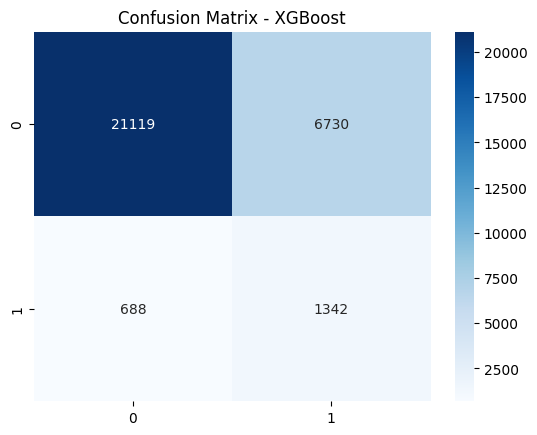

In [25]:
cm = confusion_matrix(y_test, xgb_pred)
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.title("Confusion Matrix - XGBoost")
plt.show()

## 15. Model Comparison

In [26]:
results = pd.DataFrame({
    "Model": ["Logistic", "Decision Tree", "XGBoost"],
    "Accuracy": [
        accuracy_score(y_test, lr_pred),
        accuracy_score(y_test, dt_pred),
        accuracy_score(y_test, xgb_pred)
    ],
    "AUC": [
        roc_auc_score(y_test, lr_prob),
        roc_auc_score(y_test, dt_prob),
        roc_auc_score(y_test, xgb_prob)
    ]
})

results

,Model,Accuracy,AUC
0,Logistic,0.919509,0.696496
1,Decision Tree,0.739784,0.632416
2,XGBoost,0.751732,0.783202


## 16. ROC Curve

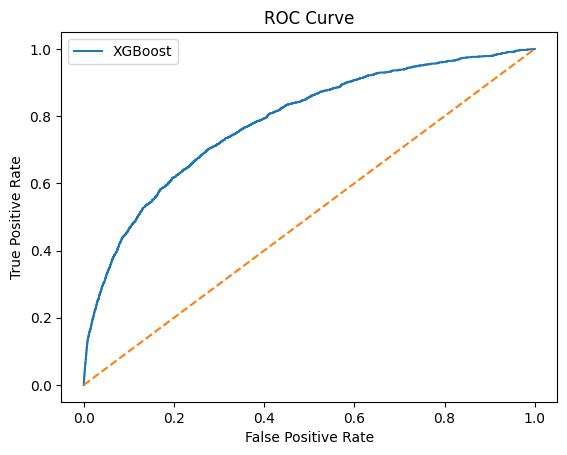

In [27]:
fpr, tpr, _ = roc_curve(y_test, xgb_prob)

plt.plot(fpr, tpr, label="XGBoost")
plt.plot([0,1], [0,1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

## 17. SHAP Explainability

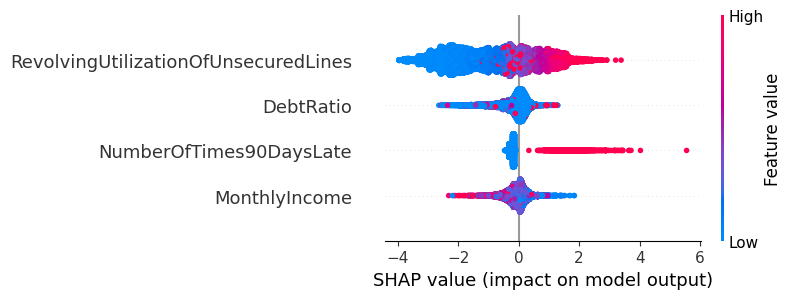

In [28]:
explainer = shap.TreeExplainer(xgb)
shap_values = explainer.shap_values(X_test)

shap.summary_plot(shap_values, X_test)

## 18. Save Model

In [33]:
import pickle

# Save model inside models folder
with open(r"C:\ML_Projects\Credit_Default_Project\models\model.pkl", "wb") as f:
    pickle.dump(xgb, f)

# Save columns inside models folder
with open(r"C:\ML_Projects\Credit_Default_Project\models\columns.pkl", "wb") as f:
    pickle.dump(X.columns, f)

print("✅ Saved inside models folder!")

✅ Saved inside models folder!


## 🧠 Business Interpretation
Customers with high debt ratio, low income, and frequent late payments are more likely to default.

## ✅ Conclusion
XGBoost performed best and SHAP provided clear explainability of risk factors.